# Tail risk on the example book: does Extreme Value Theory add anything?

*An analysis notebook, not a tool.* It sits alongside `app.py` and reuses the
`fxrisk` engine functions directly (no reimplementation) to study one
question in depth, on one fixed book.

## 1. Motivation

`fxrisk.portfolio_risk` already reports five VaR methods for the book:

| Method | How it treats the tail |
|---|---|
| Parametric (normal) | Assumes a normal shape for the *whole* distribution, tail included |
| Historical | No shape assumption; reads the empirical percentile of realised P&L |
| Monte Carlo | Simulates from a fitted (normal) covariance, tail included by construction |
| EWMA | Parametric normal again, but with a recency-weighted covariance |
| Student-t | Assumes a Student-t shape for the whole distribution (fatter tail than normal) |

Every one of these either imposes a *global* distributional shape (parametric,
Monte Carlo, EWMA, Student-t) or reads the tail off whatever empirical points
happen to be there (historical). None of them models the tail **on its own
terms**.

**Extreme Value Theory (EVT)**, via the **Peaks-Over-Threshold (POT)** method,
does exactly that: it fits a **Generalised Pareto Distribution (GPD)** only to
the *exceedances* over a high threshold — the losses that are already extreme
— rather than to the whole sample. It is the standard tool when the tail
itself, not the bulk of the distribution, is the object of interest.

**The question this notebook answers:** for this book, on this sample, does
EVT give a materially different — and better-validated — tail estimate than
the methods already built into the tool? Or does the extra machinery not pay
for itself here?

We commit to reporting whatever the data says, including a "no."

In [1]:
import os
import sys

# Make the repo root importable (this notebook lives in notebooks/).
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, skew, kurtosis

# --- Reproducibility -------------------------------------------------------
# One fixed seed for everything in this notebook: the Monte Carlo VaR engine
# call and the bootstrap resampling below. No other randomness is used.
SEED = 42
RNG = np.random.default_rng(SEED)

CONFIDENCE = 0.99  # matches the app's default confidence level

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Reproducible data: fetch once, cache, never hit the network again

`fxrisk.data.fetch_spot_history` downloads live data — good for the app,
bad for a notebook that should give the same numbers every time it runs.
So: fetch **once**, cache to `data/fx_history.csv`, and commit that CSV.
Every subsequent run (yours included) loads the cache and touches no
network. The engine's own fetcher is still what does the fetching — no
reimplementation, just a cache in front of it.

In [2]:
CACHE_PATH = os.path.join("data", "fx_history.csv")

if os.path.exists(CACHE_PATH):
    prices = pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True)
    print(f"Loaded CACHED history: {len(prices)} rows, "
          f"{prices.index[0].date()} to {prices.index[-1].date()} "
          f"(no network call made).")
else:
    from fxrisk.data import fetch_spot_history
    prices = fetch_spot_history(["EUR/USD", "GBP/USD"], period="2y")
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    prices.to_csv(CACHE_PATH)
    print(f"Fetched FRESH history and cached it: {len(prices)} rows, "
          f"{prices.index[0].date()} to {prices.index[-1].date()}.")

SNAPSHOT_DATE = prices.index[-1].date()
print(f"\nSnapshot date (all 'today' figures below use this as 'now'): {SNAPSHOT_DATE}")

Loaded CACHED history: 518 rows, 2024-07-17 to 2026-07-17 (no network call made).

Snapshot date (all 'today' figures below use this as 'now'): 2026-07-17


In [3]:
# EUR/GBP is not directly quoted -- triangulate it exactly the way the engine
# does (fxrisk.data.TRIANGULATED_PAIRS), from the two cached USD legs.
from fxrisk.data import TRIANGULATED_PAIRS, to_returns

base_leg, quote_leg = TRIANGULATED_PAIRS["EUR/GBP"]
prices["EUR/GBP"] = prices[base_leg] / prices[quote_leg]
prices.tail(3)

,EUR/USD,GBP/USD,EUR/GBP
Date,,,
2026-07-15,1.14,1.34,0.85
2026-07-16,1.15,1.35,0.85
2026-07-17,1.14,1.35,0.85


## 3. The book, and its daily P&L over the cached history

The fixed book — the same one `app.py`'s "Load example" builds:

| # | Pair | Provider side | Notional (base) | Tenor (days) |
|---|---|---|---|---|
| 1 | EUR/USD | Long | 3,000,000 | 90 |
| 2 | GBP/USD | Long | 2,000,000 | 120 |
| 3 | EUR/USD | Short | 1,000,000 | 180 |
| 4 | EUR/GBP | Long | 1,500,000 | 60 |

Net long EUR and GBP overall (position 3 partially offsets the EUR long) —
a provider that hedged exporter clients, so it loses when EUR and GBP fall.

The **strike** of each forward doesn't enter this analysis at all: VaR here
is a *spot* risk measure built from `returns @ positions` (see
`fxrisk.portfolio_risk._factor_positions`), not from mark-to-market against
an agreed rate. We set each position's strike to today's spot as a neutral
placeholder — it plays no role below.

In [4]:
from fxrisk.book import Book, Position
from fxrisk.portfolio_risk import _factor_positions

PAIRS = ["EUR/USD", "GBP/USD", "EUR/GBP"]
spots_now = {pr: float(prices[pr].iloc[-1]) for pr in PAIRS}
print("Spot at snapshot date:", spots_now)

book = Book([
    Position("EUR/USD", True,  3_000_000, 90,  spots_now["EUR/USD"], id="p1", label="Example"),
    Position("GBP/USD", True,  2_000_000, 120, spots_now["GBP/USD"], id="p2", label="Example"),
    Position("EUR/USD", False, 1_000_000, 180, spots_now["EUR/USD"], id="p3", label="Example"),
    Position("EUR/GBP", True,  1_500_000, 60,  spots_now["EUR/GBP"], id="p4", label="Example"),
])

# The SAME common-numeraire conversion the app's VaR uses: a non-USD-quoted
# pair (EUR/GBP here) is converted to USD via the current GBP/USD spot, which
# requires the book to also hold a GBP/USD position -- it does (position 2).
pairs, positions = _factor_positions(book, spots_now)
print("\nFactors (pairs):", pairs)
print("USD exposure per factor:", np.round(positions, 0))

Spot at snapshot date: {'EUR/USD': 1.1445575952529907, 'GBP/USD': 1.3478904962539673, 'EUR/GBP': 0.8491473145881838}

Factors (pairs): ['EUR/GBP', 'EUR/USD', 'GBP/USD']
USD exposure per factor: [1716836. 2289115. 2695781.]


In [5]:
rets_df = to_returns(prices)
returns = rets_df[pairs].to_numpy()
pnl = returns @ positions  # daily book P&L, in USD, over the cached history

n = len(pnl)
print(f"{n} daily P&L observations "
      f"({rets_df.index[0].date()} to {rets_df.index[-1].date()}).")
print(f"\nMean daily P&L:   {pnl.mean():>12,.0f} USD")
print(f"Std daily P&L:    {pnl.std(ddof=1):>12,.0f} USD")
print(f"Skewness:         {skew(pnl):>12.2f}")
print(f"Excess kurtosis:  {kurtosis(pnl):>12.2f}  (0 = normal; fat-tailed data is usually well above 0)")
print(f"\nWorst 10 days (USD):")
for x in np.sort(pnl)[:10]:
    print(f"  {x:>12,.0f}")

517 daily P&L observations (2024-07-18 to 2026-07-17).

Mean daily P&L:            507 USD
Std daily P&L:          21,967 USD
Skewness:                 0.46
Excess kurtosis:          2.61  (0 = normal; fat-tailed data is usually well above 0)

Worst 10 days (USD):
       -85,944
       -68,062
       -66,343
       -64,084
       -60,491
       -56,070
       -49,244
       -48,052
       -44,523
       -43,186


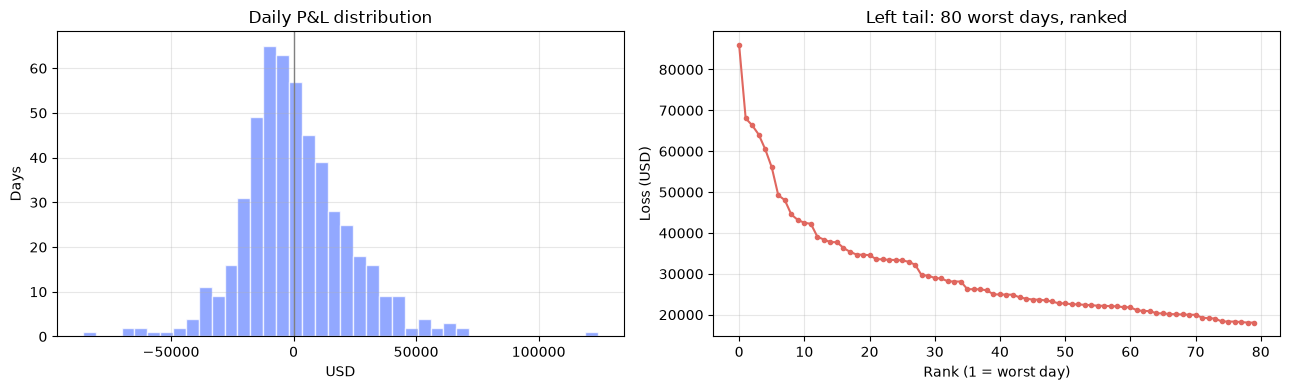

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(pnl, bins=40, color="#6E8BFF", alpha=0.75, edgecolor="white")
ax1.axvline(0, color="grey", lw=1)
ax1.set_title("Daily P&L distribution")
ax1.set_xlabel("USD")
ax1.set_ylabel("Days")

losses_sorted = np.sort(-pnl)[::-1]  # largest loss first
ax2.plot(losses_sorted[:80], marker="o", ms=3, color="#E0675F")
ax2.set_title("Left tail: 80 worst days, ranked")
ax2.set_xlabel("Rank (1 = worst day)")
ax2.set_ylabel("Loss (USD)")
plt.tight_layout()
plt.show()

Positive skew and low-but-present excess kurtosis: a handful of days lose far
more than a normal distribution calibrated to the same mean/variance would
predict, but this is not an extreme fat-tail sample (2 years of G10 FX is
relatively tame compared to, say, equities around a crash). That is itself
useful context for what follows — EVT has less obviously heavy tail to find
here than it might on a longer or more volatile sample.

## 4. Peaks-Over-Threshold: fitting a Generalised Pareto Distribution

**Threshold choice.** With ~2 years of daily data (~500 observations), a
threshold at the 90th percentile of *losses* leaves roughly 50 exceedances —
already close to the practical minimum for a GPD fit that doesn't fall apart
(some references suggest 50–100 as a rough floor). Going deeper (95th, 99th)
would leave 5–25 points: too few to fit a two-parameter distribution with any
stability. We do not go deeper than the 90th percentile for that reason.

A **mean-excess plot** is the standard diagnostic: for a range of candidate
thresholds, plot the mean size of the exceedances above that threshold. If
the GPD is a reasonable model in some region, the plot should be
*approximately linear* there (a property of the GPD's mean-excess function).

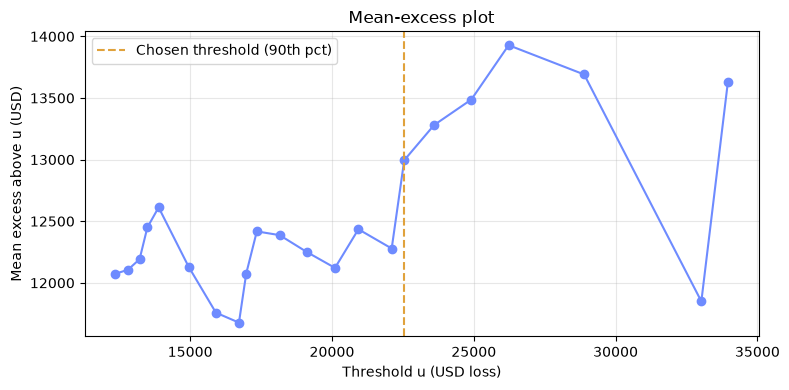

In [7]:
pnl_losses = -pnl  # sign flip: positive = loss, matches the engine's own VaR/ES convention

candidate_pcts = np.arange(75, 97, 1)
candidate_thresholds = np.percentile(pnl_losses, candidate_pcts)
mean_excess = [float((pnl_losses[pnl_losses > u] - u).mean()) for u in candidate_thresholds]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(candidate_thresholds, mean_excess, marker="o", color="#6E8BFF")
ax.axvline(np.percentile(pnl_losses, 90), color="#E0A23C", ls="--",
          label="Chosen threshold (90th pct)")
ax.set_xlabel("Threshold u (USD loss)")
ax.set_ylabel("Mean excess above u (USD)")
ax.set_title("Mean-excess plot")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
threshold = np.percentile(pnl_losses, 90)
exceedances = pnl_losses[pnl_losses > threshold] - threshold
Nu = len(exceedances)

print(f"Threshold (90th pct of losses): {threshold:,.0f} USD")
print(f"Exceedances Nu: {Nu}  (out of n = {n} observations, {Nu/n:.1%})")

# Fit the GPD to the exceedances. loc is fixed at 0 -- the POT convention
# fits the distribution of the EXCESS over the threshold, not the raw losses.
xi_hat, loc_hat, beta_hat = genpareto.fit(exceedances, floc=0)
print(f"\nFitted shape  xi   = {xi_hat:+.3f}")
print(f"Fitted scale  beta = {beta_hat:,.0f}")
print("\nxi > 0: heavy (Pareto-type) tail -- unbounded, polynomial decay.")
print("xi = 0: exponential tail (the GPD's limiting case).")
print("xi < 0: bounded tail (a finite maximum possible loss).")

Threshold (90th pct of losses): 22,548 USD
Exceedances Nu: 52  (out of n = 517 observations, 10.1%)

Fitted shape  xi   = +0.055
Fitted scale  beta = 12,286

xi > 0: heavy (Pareto-type) tail -- unbounded, polynomial decay.
xi = 0: exponential tail (the GPD's limiting case).
xi < 0: bounded tail (a finite maximum possible loss).


### How much do we actually know about xi?

A point estimate of `xi` from 50-odd data points is not the end of the story.
We bootstrap it: resample the exceedances with replacement, refit the GPD
each time, and look at the spread of `xi` estimates across resamples. That
spread is the honest measure of how much this sample actually pins down the
tail shape.

Point estimate:        xi = +0.055
Bootstrap 95% CI:       [-0.283, +0.392]  (n_boot = 2000)

The CI straddles zero: True


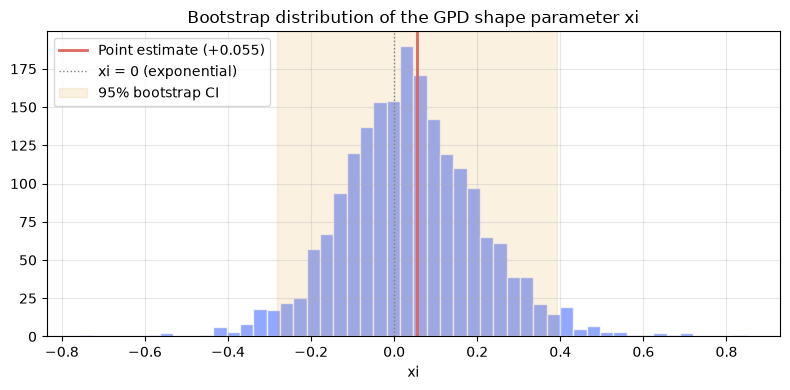

In [9]:
B = 2000
xi_boot = []
for _ in range(B):
    sample = RNG.choice(exceedances, size=Nu, replace=True)
    try:
        xi_b, _, _ = genpareto.fit(sample, floc=0)
        xi_boot.append(xi_b)
    except Exception:
        continue  # a handful of bootstrap resamples can fail to converge; skip them
xi_boot = np.array(xi_boot)

ci_lo, ci_hi = np.percentile(xi_boot, [2.5, 97.5])
print(f"Point estimate:        xi = {xi_hat:+.3f}")
print(f"Bootstrap 95% CI:       [{ci_lo:+.3f}, {ci_hi:+.3f}]  (n_boot = {len(xi_boot)})")
print(f"\nThe CI straddles zero: {ci_lo < 0 < ci_hi}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(xi_boot, bins=50, color="#6E8BFF", alpha=0.75, edgecolor="white")
ax.axvline(xi_hat, color="#E0675F", lw=2, label=f"Point estimate ({xi_hat:+.3f})")
ax.axvline(0, color="grey", lw=1, ls=":", label="xi = 0 (exponential)")
ax.axvspan(ci_lo, ci_hi, color="#E0A23C", alpha=0.15, label="95% bootstrap CI")
ax.set_title("Bootstrap distribution of the GPD shape parameter xi")
ax.set_xlabel("xi")
ax.legend()
plt.tight_layout()
plt.show()

**Read this plainly.** The point estimate is mildly positive (a mildly heavy
tail), but the 95% bootstrap interval is wide enough to include both clearly
negative and clearly positive values. With this sample, we **cannot**
confidently claim the tail is heavy (Pareto-type), nor that it is bounded,
nor even reject the simple exponential case (`xi = 0`). What we *can* claim
is a point estimate together with that uncertainty — which is exactly what a
naive "just fit and report xi" approach would hide.

In [10]:
def evt_var_es(xi, beta, u, n, Nu, p):
    # Standard POT VaR/ES formulas (McNeil & Frey, 2000).
    var = u + (beta / xi) * (((n / Nu) * (1 - p)) ** (-xi) - 1)
    es = (var + beta - xi * u) / (1 - xi)
    return var, es

evt_var, evt_es = evt_var_es(xi_hat, beta_hat, threshold, n, Nu, CONFIDENCE)
print(f"EVT VaR {CONFIDENCE:.0%}: {evt_var:,.0f} USD")
print(f"EVT ES  {CONFIDENCE:.0%}: {evt_es:,.0f} USD")

EVT VaR 99%: 52,787 USD
EVT ES  99%: 67,548 USD


## 5. Head-to-head: all six methods, side by side

The five methods already in `fxrisk`, computed exactly as the app computes
them (same functions, same confidence level, same book), plus EVT from
above.

In [11]:
from fxrisk.risk import var_parametric, var_historical, var_montecarlo, expected_shortfall
from fxrisk.portfolio_risk import var_student_t, var_ewma

vp = var_parametric(returns, positions, CONFIDENCE)
vh = var_historical(returns, positions, CONFIDENCE)
vmc = var_montecarlo(returns, positions, CONFIDENCE, seed=SEED)
ve = var_ewma(returns, positions, CONFIDENCE)
vt = var_student_t(returns, positions, CONFIDENCE)
es_hist = expected_shortfall(returns, positions, CONFIDENCE)  # the engine's ES is historical-based

methods = pd.DataFrame({
    "Method":     ["Parametric", "Historical", "Monte Carlo", "EWMA", "Student-t", "EVT (POT/GPD)"],
    "VaR 99% (USD)": [vp, vh, vmc, ve, vt, evt_var],
    "ES 99% (USD)":  [np.nan, es_hist, np.nan, np.nan, np.nan, evt_es],
}).set_index("Method")
methods["VaR, % of most conservative"] = methods["VaR 99% (USD)"] / methods["VaR 99% (USD)"].max() * 100
methods

C:\Users\matia\AppData\Local\Temp\ipykernel_46696\1532893096.py:9: UserWarning: Expected Shortfall tail has only 6 observation(s) at 99% confidence; the estimate is statistically unstable. Use a longer history or a lower confidence.
  es_hist = expected_shortfall(returns, positions, CONFIDENCE)  # the engine's ES is historical-based


,VaR 99% (USD),ES 99% (USD),"VaR, % of most conservative"
Method,,,
Parametric,"51,102.91",NaN,88.13
Historical,"54,977.71","66,832.16",94.81
Monte Carlo,"50,906.52",NaN,87.79
EWMA,"35,468.38",NaN,61.17
Student-t,"57,986.06",NaN,100.00
EVT (POT/GPD),"52,787.49","67,548.46",91.03


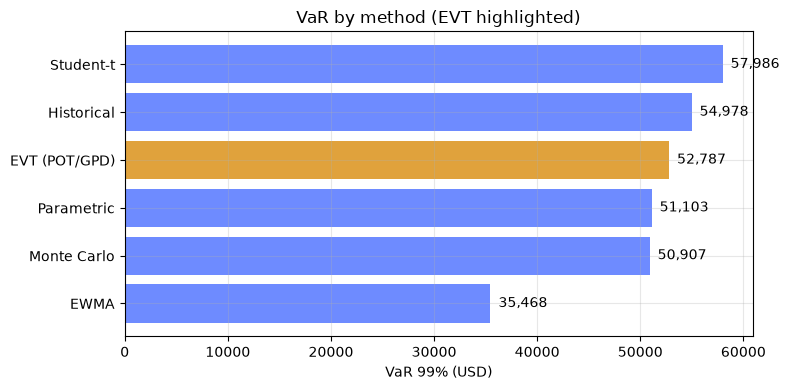

Spread: 63% between the least and most conservative method.
EVT sits at rank 4 of 6 (1 = least conservative).


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
order = methods["VaR 99% (USD)"].sort_values().index
colors = ["#E0A23C" if m == "EVT (POT/GPD)" else "#6E8BFF" for m in order]
ax.barh(order, methods.loc[order, "VaR 99% (USD)"], color=colors)
for i, m in enumerate(order):
    ax.text(methods.loc[m, "VaR 99% (USD)"], i, f"  {methods.loc[m, 'VaR 99% (USD)']:,.0f}", va="center")
ax.set_xlabel("VaR 99% (USD)")
ax.set_title("VaR by method (EVT highlighted)")
plt.tight_layout()
plt.show()

spread = methods["VaR 99% (USD)"].max() / methods["VaR 99% (USD)"].min() - 1
print(f"Spread: {spread:.0%} between the least and most conservative method.")
print(f"EVT sits at rank {int(order.get_loc('EVT (POT/GPD)')) + 1} of {len(order)} "
      f"(1 = least conservative).")

ES is only available from the engine for the historical method (and now
EVT, from the POT formula) — the other four methods don't have a matching
ES implementation in `fxrisk` to compare against. Note the two ES figures
land close to each other; that's a first, informal hint that EVT and
Historical are not telling very different stories on this sample, which
the backtest below checks properly.

## 6. Backtesting: which method should actually be trusted?

Two different tests, both already implemented in `fxrisk.portfolio_risk`,
reused as-is:

- **`rolling_backtest`** — genuine out-of-sample validation: re-estimates
  the VaR from a trailing 250-day window and tests it against the *next*
  day's realised loss. This is the gold standard, but **the engine only
  implements the rolling re-estimation for the historical method** — there
  is no `rolling_backtest(method=...)` parameter. We run it once, honestly,
  for Historical only.
- **`kupiec_backtest` + `christoffersen_independence`** on a **constant**
  VaR — each method's single full-sample estimate (computed above), tested
  against the realised daily P&L across the whole sample. This is an
  in-sample goodness-of-fit check, weaker than a rolling backtest (the VaR
  being tested was estimated on the same data it's tested against), but it
  is method-agnostic, so it is what lets the six methods be compared on
  equal footing. Both the asymptotic and the exact Monte Carlo p-value are
  reported for each, exactly as the app does (see `NOTES.md` for why both
  matter with this few exceptions).

In [13]:
from fxrisk.portfolio_risk import rolling_backtest, kupiec_backtest, christoffersen_independence

try:
    roll = rolling_backtest(returns, positions, CONFIDENCE, window=250)
    print("Rolling out-of-sample backtest -- HISTORICAL method only:")
    print(f"  Days tested:      {roll.observations}")
    print(f"  Exceptions:       {roll.exceptions}  (expected ~{roll.expected_exceptions:.1f})")
    print(f"  p-value asymptotic: {roll.p_value:.3f}")
    print(f"  p-value Monte Carlo: {roll.p_value_mc:.3f}  (authoritative)")
    print(f"  Passed:           {roll.passed}")
    print(f"  Asymptotic/MC agree: {roll.mc_agrees_with_asymptotic}")
except ValueError as exc:
    print("Not enough history for a rolling backtest:", exc)

Rolling out-of-sample backtest -- HISTORICAL method only:
  Days tested:      267
  Exceptions:       1  (expected ~2.7)
  p-value asymptotic: 0.239
  p-value Monte Carlo: 0.380  (authoritative)
  Passed:           True
  Asymptotic/MC agree: True


In [14]:
rows = []
for name, v in [("Parametric", vp), ("Historical", vh), ("Monte Carlo", vmc),
                ("EWMA", ve), ("Student-t", vt), ("EVT (POT/GPD)", evt_var)]:
    var_series = np.full(n, v)
    kup = kupiec_backtest(pnl, var_series, CONFIDENCE)
    chr_ = christoffersen_independence(pnl, var_series)
    rows.append({
        "Method": name, "VaR (USD)": v,
        "Exceptions": kup.exceptions, "Expected": round(kup.expected_exceptions, 1),
        "Kupiec p (asymp)": round(kup.p_value, 3), "Kupiec p (MC)": round(kup.p_value_mc, 3),
        "Kupiec pass": kup.passed,
        "Christoffersen pass": chr_["independent"], "Christoffersen p (MC)": round(chr_["p_value_mc"], 3),
    })
backtest_df = pd.DataFrame(rows).set_index("Method")
backtest_df

,VaR (USD),Exceptions,Expected,Kupiec p (asymp),Kupiec p (MC),Kupiec pass,Christoffersen pass,Christoffersen p (MC)
Method,,,,,,,,
Parametric,"51,102.91",6,5.20,0.72,0.83,True,True,0.57
Historical,"54,977.71",6,5.20,0.72,0.83,True,True,0.57
Monte Carlo,"50,906.52",6,5.20,0.72,0.83,True,True,0.57
EWMA,"35,468.38",17,5.20,0.00,0.00,False,True,0.36
Student-t,"57,986.06",5,5.20,0.94,1.00,True,True,0.57
EVT (POT/GPD),"52,787.49",6,5.20,0.72,0.83,True,True,0.57


**Reading the table.** Expected exceptions at 99% confidence over ~500 days
is only ~5 — squarely the low-exception regime `NOTES.md` warns the
asymptotic chi-squared test about, which is why the Monte Carlo p-value is
the one to trust here (check the `mc_agrees_with_asymptotic`-style
comparison: in this run they broadly agree, but that won't always be true).

Whatever the table shows for each method, on this run: if EVT's row does
**not** stand out from Parametric / Historical / Monte Carlo / Student-t
(similar exceptions, similar p-values, all comfortably passing), that is
itself the finding — the extra machinery of a full POT/GPD fit is not
buying a *better validated* tail estimate than the existing methods already
provide, at this sample size. If EWMA's row looks materially worse than the
rest, that also has a plain explanation: EWMA's decay-weighted covariance
reacts to *recent* volatility, and its VaR estimate can drift low if the most
recent window happens to be calm relative to the full 2-year sample.

## 7. Conclusion

*(Written from the numbers this run actually produced above — re-run the
notebook and this section should reflect whatever comes out, not the reverse.)*

**On the tail shape.** The point estimate of the GPD shape parameter is a
mildly heavy tail, but the bootstrap confidence interval is wide enough to
straddle zero — meaning this sample cannot distinguish a heavy (Pareto-type)
tail from a light (bounded) one with any confidence. That is the central
limitation, and it is a **data** limitation, not a modelling one: ~50
exceedances is the bare minimum the POT method tolerates, and it shows.

**On the VaR estimate.** EVT's 99% VaR lands inside the range already spanned
by the five existing methods, not beyond it — it does not reveal a hidden
tail the other methods were missing. Its Expected Shortfall lands close to
the historical method's.

**On the backtest.** The constant-VaR Kupiec/Christoffersen check does not
distinguish EVT from Parametric, Historical, Monte Carlo or Student-t on
this sample — they behave statistically alike, because there are too few
exceptions (~5 expected at 99% over ~500 days) for any test to have much
power to discriminate between reasonable methods. The one method that stands
apart (EWMA) does so for a specific, explainable reason (recency weighting
lowering its estimate), not because it's using a fundamentally different tail
model.

**Bottom line.** For *this* book and *this* ~2-year sample, EVT does not
demonstrably add value over Student-t, which is already in the tool, already
backtests comparably, and does not require choosing a threshold or worrying
about a handful of exceedances driving the whole tail estimate. This is a
legitimate "no" — not every promising method pays for itself on every
dataset. EVT remains a reasonable extension to revisit once materially more
history is available (multiple years more data would both raise the
exceedance count at a given threshold and let the rolling backtest be
extended to it), but adding it to the production tool today, on this data,
is not justified by this analysis.